# Notebook 3 - Data Preprocessing

## Why this notebook exists

Raw data is not ready for machine learning. Models need:

- no blank cells
- numbers instead of text labels
- fair train / test separation
- features that match the business patterns found in notebook 2

This notebook turns `step1_customers.csv` into model-ready tables.

| | |
|---|---|
| **Input** | `data/clean/step1_customers.csv` |
| **Output** | `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, plus ID files and a short meta JSON |
| **Why it is needed** | Every modelling notebook (4–8) reads these processed files. If this step is wrong, later scores are meaningless. |

## What we will do

1. Harmonise messy category labels
2. Create a few simple engineered features
3. Split into train (80%) and test (20%) **before** learning fill/scale values
4. Fill missing values using **train** statistics only
5. Encode text columns as 0/1 columns
6. Scale continuous numbers with RobustScaler
7. Save everything for later notebooks

## Step 0 - Tools and file locations

We keep imports small:

- `os`, `json` - folders and a tiny summary file
- `pandas` - tables
- `matplotlib` - a few check charts
- `train_test_split` - fair split
- `RobustScaler` - scale numbers using median and IQR (good with outliers)

In [1]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

RANDOM_SEED = 42
CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"

os.makedirs(CLEAN_FOLDER, exist_ok=True)
os.makedirs(FIGURE_FOLDER, exist_ok=True)

customers = pd.read_csv(CLEAN_FOLDER + "/step1_customers.csv")
print("Loaded shape:", customers.shape)
customers.head()

Loaded shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Step 1 - Harmonise category labels

Notebook 2 showed the same meaning written two ways. We fix that now so
one-hot encoding does not create duplicate columns.

In [2]:
df = customers.copy()

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace(
    {"Phone": "Mobile Phone"}
)
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace(
    {"CC": "Credit Card", "COD": "Cash on Delivery"}
)
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace(
    {"Mobile": "Mobile Phone"}
)

print("Login devices:", df["PreferredLoginDevice"].unique().tolist())
print("Payment modes:", df["PreferredPaymentMode"].unique().tolist())
print("Order categories:", df["PreferedOrderCat"].unique().tolist())

Login devices: ['Mobile Phone', 'Computer']
Payment modes: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
Order categories: ['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']


## Step 2 - Feature engineering (simple new columns)

From notebook 2 we create three helpful columns:

| New column | Meaning |
|---|---|
| `TenureBin` | Tenure life-stage: 0=New, 1=Early, 2=Mid, 3=Long |
| `IsDormant` | 1 if days since last order is above the **train** median |
| `UnhappyComplain` | 1 if customer complained AND satisfaction ≤ 2 |

`TenureBin` uses fixed cut points, so we can create it before the split.
`IsDormant` needs the train median, so we create it **after** the split.

In [3]:
# Fixed bins from the EDA tenure cohorts
# Missing Tenure becomes NaN here; we fill it after the split using train median.
df["TenureBin"] = pd.cut(
    df["Tenure"],
    bins=[-0.1, 3, 9, 15, 1e9],
    labels=[0, 1, 2, 3],
)
df["TenureBin"] = df["TenureBin"].astype("float")

# Complaint + low satisfaction interaction (can create before split:
# it only uses each row's own values, so it does not leak test statistics)
df["UnhappyComplain"] = (
    (df["Complain"].fillna(0) == 1) & (df["SatisfactionScore"].fillna(3) <= 2)
).astype(int)

print("TenureBin value counts:")
print(df["TenureBin"].value_counts(dropna=False).sort_index())
print()
print("UnhappyComplain value counts:")
print(df["UnhappyComplain"].value_counts())

TenureBin value counts:
TenureBin
0.0    1560
1.0    1321
2.0    1105
3.0    1380
NaN     264
Name: count, dtype: int64

UnhappyComplain value counts:
UnhappyComplain
0    5088
1     542
Name: count, dtype: int64


## Step 3 - Train / test split (before learning any fill values)

**Why split first?**

If we fill blanks using the median of *all* customers, the test set secretly
helps choose that median. That is called **data leakage**. The model then looks
better on the test set than it would on truly new customers.

We use an **80/20 stratified** split:

- 80% train — the model learns from this
- 20% test — we only use this for final scoring
- `stratify=y` keeps the churn rate similar in both sets
- `random_state=42` makes the split reproducible

In [4]:
TARGET = "Churn"
ID_COL = "CustomerID"

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train rows:", X_train.shape[0], "| churn rate:", round(y_train.mean(), 4))
print("Test rows :", X_test.shape[0], "| churn rate:", round(y_test.mean(), 4))

# Keep IDs separately for later prediction examples; drop from modelling tables
id_train = X_train[[ID_COL]].copy()
id_test = X_test[[ID_COL]].copy()
X_train = X_train.drop(columns=[ID_COL]).copy()
X_test = X_test.drop(columns=[ID_COL]).copy()

print("CustomerID removed from model inputs.")

Train rows: 4504 | churn rate: 0.1683
Test rows : 1126 | churn rate: 0.1687
CustomerID removed from model inputs.


## Step 4 - Fill missing values (train statistics only)

| Column type | Fill method | Why |
|---|---|---|
| Continuous / ordinal numbers | **median** of the train column | Resistant to skew and outliers |
| Text categories | **most common** train value (mode) | Sensible default for a label |

We learn the fill values from `X_train`, then apply the same values to `X_test`.

In [5]:
numeric_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
    "CityTier",
    "SatisfactionScore",
    "Complain",
    "TenureBin",
]

category_columns = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
]

# Remember missing % on train BEFORE filling (for a chart)
missing_before = []
for column_name in numeric_columns + category_columns:
    percent = X_train[column_name].isna().mean() * 100
    if percent > 0:
        missing_before.append([column_name, percent])

missing_before_table = pd.DataFrame(missing_before, columns=["feature", "missing_percent"])

# Learn fill values from TRAIN only
numeric_fill_values = {}
for column_name in numeric_columns:
    numeric_fill_values[column_name] = X_train[column_name].median()

category_fill_values = {}
for column_name in category_columns:
    category_fill_values[column_name] = X_train[column_name].mode().iloc[0]

# Apply the same fill values to train and test
for column_name in numeric_columns:
    fill_value = numeric_fill_values[column_name]
    X_train[column_name] = X_train[column_name].fillna(fill_value)
    X_test[column_name] = X_test[column_name].fillna(fill_value)

for column_name in category_columns:
    fill_value = category_fill_values[column_name]
    X_train[column_name] = X_train[column_name].fillna(fill_value)
    X_test[column_name] = X_test[column_name].fillna(fill_value)

print("Train missing cells after fill:", int(X_train.isna().sum().sum()))
print("Test missing cells after fill :", int(X_test.isna().sum().sum()))
print()
print("Example numeric fill values (medians):")
for column_name in ["Tenure", "DaySinceLastOrder", "OrderCount"]:
    print(" ", column_name, "=", numeric_fill_values[column_name])
print()
print("Example category fill values (modes):")
for column_name in category_columns:
    print(" ", column_name, "=", category_fill_values[column_name])

Train missing cells after fill: 0
Test missing cells after fill : 0

Example numeric fill values (medians):
  Tenure = 9.0
  DaySinceLastOrder = 3.0
  OrderCount = 2.0

Example category fill values (modes):
  PreferredLoginDevice = Mobile Phone
  PreferredPaymentMode = Debit Card
  Gender = Male
  PreferedOrderCat = Mobile Phone
  MaritalStatus = Married


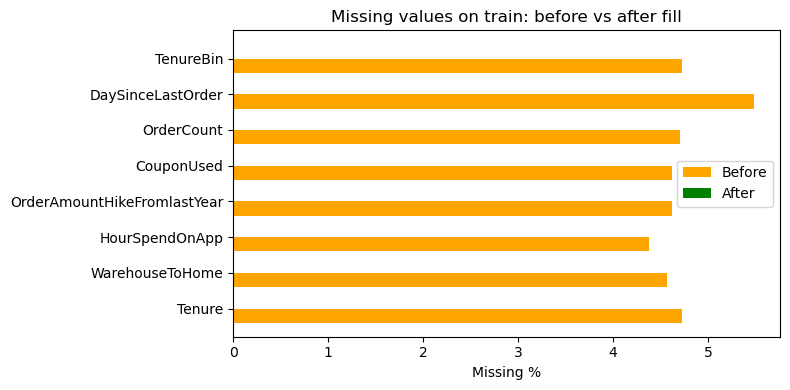

In [6]:
# Chart: missing % before vs after (after should be 0)
plt.figure(figsize=(8, 4))
if len(missing_before_table) > 0:
    features = missing_before_table["feature"].tolist()
    before_vals = missing_before_table["missing_percent"].tolist()
    after_vals = [0] * len(features)
    y_pos = list(range(len(features)))

    plt.barh([p - 0.2 for p in y_pos], before_vals, height=0.4, label="Before", color="orange")
    plt.barh([p + 0.2 for p in y_pos], after_vals, height=0.4, label="After", color="green")
    plt.yticks(y_pos, features)
else:
    plt.text(0.5, 0.5, "No missing values on train", ha="center")

plt.xlabel("Missing %")
plt.title("Missing values on train: before vs after fill")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/3_missing_before_after.png", dpi=150)
plt.show()

## Step 5 - Create `IsDormant` using the train median

A customer is marked dormant if their `DaySinceLastOrder` is above the typical
(train) value. Using the train median avoids peeking at the test set.

In [7]:
recency_threshold = X_train["DaySinceLastOrder"].median()

X_train["IsDormant"] = (X_train["DaySinceLastOrder"] > recency_threshold).astype(int)
X_test["IsDormant"] = (X_test["DaySinceLastOrder"] > recency_threshold).astype(int)

print("Recency threshold (train median of DaySinceLastOrder):", recency_threshold)
print("Train dormant share:", round(X_train["IsDormant"].mean(), 3))
print("Test dormant share :", round(X_test["IsDormant"].mean(), 3))

Recency threshold (train median of DaySinceLastOrder): 3.0
Train dormant share: 0.447
Test dormant share : 0.452


## Step 6 - Encode text columns (one-hot)

Machine learning models need numbers. **One-hot encoding** turns each category
into its own 0/1 column.

Example: `Gender` with Male / Female becomes:

- `Gender_Female`
- `Gender_Male`

We encode train first, then align test columns to the same list. If a rare
category appears only in test, its column is filled with 0.

In [8]:
# Separate numeric-ish columns from text columns
ordinal_and_flags = [
    "CityTier",
    "SatisfactionScore",
    "Complain",
    "TenureBin",
    "IsDormant",
    "UnhappyComplain",
]
continuous_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

X_train_num = X_train[continuous_columns + ordinal_and_flags].copy()
X_test_num = X_test[continuous_columns + ordinal_and_flags].copy()

X_train_cat = pd.get_dummies(X_train[category_columns], dtype=int)
X_test_cat = pd.get_dummies(X_test[category_columns], dtype=int)

# Make test columns match train columns exactly
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

print("One-hot columns created:", X_train_cat.shape[1])
print("Examples:", list(X_train_cat.columns[:8]))

One-hot columns created: 17
Examples: ['PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Female']


## Step 7 - Scale continuous numbers with RobustScaler

**RobustScaler** subtracts the median and divides by the IQR. Compared with
StandardScaler (mean / standard deviation), it is less pulled by outliers.
That matches notebook 2, where several spend/distance columns had long tails.

We fit the scaler on **train continuous columns only**, then transform train
and test with those same numbers. Ordinal flags stay as-is.

In [9]:
scaler = RobustScaler()

X_train_continuous_scaled = scaler.fit_transform(X_train_num[continuous_columns])
X_test_continuous_scaled = scaler.transform(X_test_num[continuous_columns])

X_train_continuous = pd.DataFrame(
    X_train_continuous_scaled,
    columns=continuous_columns,
    index=X_train_num.index,
)
X_test_continuous = pd.DataFrame(
    X_test_continuous_scaled,
    columns=continuous_columns,
    index=X_test_num.index,
)

X_train_ordinal = X_train_num[ordinal_and_flags].copy()
X_test_ordinal = X_test_num[ordinal_and_flags].copy()

# Final model matrices
X_train_final = pd.concat([X_train_continuous, X_train_ordinal, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_continuous, X_test_ordinal, X_test_cat], axis=1)

# Reset index so saved CSVs are clean row 0..n
X_train_final = X_train_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
id_train = id_train.reset_index(drop=True)
id_test = id_test.reset_index(drop=True)

print("Final train shape:", X_train_final.shape)
print("Final test shape :", X_test_final.shape)
print("Feature count    :", X_train_final.shape[1])
print("First 12 features:", list(X_train_final.columns[:12]))

Final train shape: (4504, 33)
Final test shape : (1126, 33)
Feature count    : 33
First 12 features: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'CityTier', 'SatisfactionScore']


## Step 8 - Visual checks

Two quick checks before we save:

1. Train and test churn rates should be similar (stratify worked).
2. Feature count grows after one-hot encoding (expected).

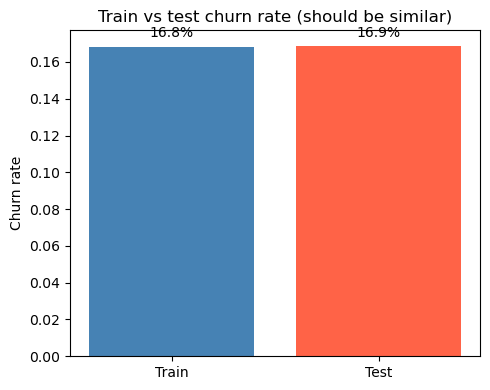

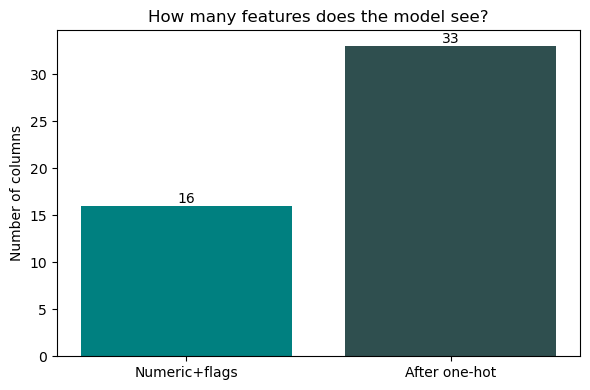

Columns before one-hot: 16
Columns after one-hot : 33


In [10]:
plt.figure(figsize=(5, 4))
rates = [float(y_train.mean()), float(y_test.mean())]
plt.bar(["Train", "Test"], rates, color=["steelblue", "tomato"])
plt.ylabel("Churn rate")
plt.title("Train vs test churn rate (should be similar)")
for i in range(len(rates)):
    plt.text(i, rates[i] + 0.005, str(round(rates[i] * 100, 1)) + "%", ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/3_train_test_churn.png", dpi=150)
plt.show()

# Feature count growth: raw inputs -> after FE flags -> after encode/scale
n_raw = len(continuous_columns) + 3 + len(category_columns)
# CityTier, SatisfactionScore, Complain were already in raw; TenureBin/IsDormant/Unhappy are new
# Simpler story for the chart:
n_after_fe = X_train_num.shape[1]  # continuous + ordinal/flags before one-hot
n_final = X_train_final.shape[1]

plt.figure(figsize=(6, 4))
steps = ["Numeric+flags", "After one-hot"]
vals = [n_after_fe, n_final]
plt.bar(steps, vals, color=["teal", "darkslategray"])
plt.ylabel("Number of columns")
plt.title("How many features does the model see?")
for i in range(len(vals)):
    plt.text(i, vals[i] + 0.3, str(vals[i]), ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/3_feature_count_steps.png", dpi=150)
plt.show()

print("Columns before one-hot:", n_after_fe)
print("Columns after one-hot :", n_final)

## Step 9 - Save processed tables

Later notebooks only need these files. We also save a tiny JSON summary so we
can quote train size / feature count without re-running everything.

In [11]:
X_train_final.to_csv(CLEAN_FOLDER + "/X_train.csv", index=False)
X_test_final.to_csv(CLEAN_FOLDER + "/X_test.csv", index=False)
y_train.to_csv(CLEAN_FOLDER + "/y_train.csv", index=False, header=["Churn"])
y_test.to_csv(CLEAN_FOLDER + "/y_test.csv", index=False, header=["Churn"])
id_train.to_csv(CLEAN_FOLDER + "/id_train.csv", index=False)
id_test.to_csv(CLEAN_FOLDER + "/id_test.csv", index=False)

# Save the feature name list for GA/PSO/TabNet notebooks
feature_names = list(X_train_final.columns)
pd.Series(feature_names, name="feature").to_csv(
    CLEAN_FOLDER + "/feature_names.csv", index=False
)

meta = {
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "n_features": int(len(feature_names)),
    "train_churn_rate": float(y_train.mean()),
    "test_churn_rate": float(y_test.mean()),
    "recency_threshold": float(recency_threshold),
    "random_seed": RANDOM_SEED,
}

with open(CLEAN_FOLDER + "/preprocess_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved processed tables to", CLEAN_FOLDER)
print(meta)

Saved processed tables to ../data/clean
{'n_train': 4504, 'n_test': 1126, 'n_features': 33, 'train_churn_rate': 0.16829484902309058, 'test_churn_rate': 0.16873889875666073, 'recency_threshold': 3.0, 'random_seed': 42}


## Conclusion of notebook 3

We now have clean numeric tables ready for baselines, GA, PSO, and TabNet.

**Files created**

- `data/clean/X_train.csv`, `X_test.csv`
- `data/clean/y_train.csv`, `y_test.csv`
- `data/clean/id_train.csv`, `id_test.csv`
- `data/clean/feature_names.csv`
- `data/clean/preprocess_meta.json`
- `figures/3_missing_before_after.png`, `3_train_test_churn.png`, `3_feature_count_steps.png`

**Next:** notebook 4 trains Logistic Regression and Random Forest baselines.